# Constrained Sinkhorn algorithm

Standard Sinkhorn optimal transport finds the cheapest way to move mass from a source distribution to a target distribution under entropy regularisation. In many applications we additionally need the transport plan $P$ to satisfy linear inequality and equality constraints.

In this notebook we will explore the Constrained Sinkhorn algorithm, introduced with the article https://openreview.net/forum?id=V5kCKFav9j in 2024-2025

In [1]:

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ott.geometry import geometry, pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn


## 1. DGP — 2-D Gaussian mixtures
We create two balanced point clouds, each made of two Gaussian clusters:

In [ ]:
rng  = np.random.default_rng(42)
n    = 30
half = n // 2
std  = 0.25
xs_np = np.vstack([
    rng.standard_normal((half, 2)) * std + [-2.0,  1.0],
    rng.standard_normal((half, 2)) * std + [ 2.0,  1.0],
])
xt_np = np.vstack([
    rng.standard_normal((half, 2)) * std + [-2.0, -1.0],
    rng.standard_normal((half, 2)) * std + [ 2.0, -1.0],
])
xs = jnp.array(xs_np)# (30, 2) size
xt = jnp.array(xt_np)# (30, 2)
theta   = 50.0
epsilon = 1.0 / theta

r = jnp.ones(n) / n
c = jnp.ones(n) / n


building Cost matrix using PointCloud

In [ ]:
# PointCloud: build geometry from 2-D coordinates
# cost_matrix is computed  as squared-Euclidean distances
geom_pc = pointcloud.PointCloud(xs, xt, epsilon=epsilon)
C       = geom_pc.cost_matrix#(30, 30)



## 2. Unconstrained baseline (standard OTT-JAX Sinkhorn)

Now Use ott jax library sinkhorn algorithm 

In [ ]:
ot_prob = linear_problem.LinearProblem(geom_pc, r, c)
ot_out  = sinkhorn.Sinkhorn()(ot_prob)
P_free  = ot_out.matrix #(30, 30) size

print(f"Unconstrained OT cost : {float(ot_out.reg_ot_cost):.4f}")
print(f"Converged             : {ot_out.converged}")

Unconstrained OT cost : 4.2765
Converged             : True


## 3. Constrained Sinkhorn implementation 




For $k = 1, \ldots, K$, let $s_k \geq 0$ be the slack variable associated with the
$k$-th inequality constraint matrix $D_k$.  The constrained entropic OT problem reads:

$$
\min_{\substack{P,\, s_1,\ldots,s_K \\ P\mathbf{1}=r,\; P^\top\mathbf{1}=c \\ P \geq 0,\; s_k \geq 0\;\forall k}}
\langle C, P \rangle + \frac{1}{\eta}\,\mathcal{H}(P, s_1, \ldots, s_K)
\tag{1}
$$

subject to

$$
\langle D_k,\, P \rangle = s_k, \quad k = 1, \ldots, K, \tag{inequality constraints}
$$

$$
\langle D_{l+K},\, P \rangle = 0, \quad l = 1, \ldots, L, \tag{equality constraints}
$$



For details refer to the article 




### 3.1 Constraint design

In this notebook I add only one inequality constraint, with no equality constraints :

$$
\langle P,\, D \rangle \;\ge\; 0, \qquad
D_{ij} = {-\,x^{(s)}_i \cdot x^{(t)}_j\;  }
$$

Here $x^{(s)}_i, x^{(t)}_j$ are the x-coordinates of source point $i$ and target point $j$.

* For same-cluster pairs: $x^{(s)} x^{(t)} > 0$ → $D < 0$.
* For cross-cluster pairs: $x^{(s)} x^{(t)} < 0$ → $D > 0$.

Requiring $\langle P, D \rangle \ge 0$ therefore penalises same-cluster transport, so we will end up more in cross cluster mappings 


In [ ]:
K = 1 # K is inequality constraint 

def build_D(xs: jnp.ndarray, xt: jnp.ndarray):
    n     = xs.shape[0]
    D_raw = -(xs[:, 0:1] * xt[:, 0].reshape(1, -1))# (n, n)
    return ((D_raw ) )[:, :, jnp.newaxis]# (n, n, 1)

### 3.2 Function we optimize



From the article, we use the function
$$
f(x, y, a) =
-\frac{1}{\eta}\sum_{ij}
\exp\!\Bigl(\eta\Bigl(-C_{ij}
+ \sum_{m=1}^{L+K} a_m (D_m)_{ij}
+ x_i + y_j\Bigr) - 1\Bigr)
+ \sum_i x_i r_i + \sum_j y_j c_j
- \frac{1}{\eta}\sum_{k=1}^{K} \exp(-\eta a_k - 1).
\tag{2}
$$

As a consequence of the minimax theorem, maximising $f$ over
$(x, y, a)$ is equivalent to solving the problem defined in equation (1).
Refer to the article for more details 

### 3.3 Sinkhorn algorithm 

In order to solve (1) the following algorithm is proposed : 



**Require:** $f,\; x_{\text{init}},\; y_{\text{init}},\; a_{\text{init}},\; N,\; i=0,\; \epsilon > 0$



**while** $i < N$ **do**

$\qquad i \leftarrow i + 1$

$\qquad P \leftarrow \exp\!\left(\eta\!\left(-C + \sum_m a_m D_m + x\mathbf{1}^\top + \mathbf{1}y^\top\right) - 1\right)$

$\qquad x \leftarrow x + \left(\log(r) - \log(P\mathbf{1})\right)/\eta$

$\qquad P \leftarrow \exp\!\left(\eta\!\left(-C + \sum_m a_m D_m + x\mathbf{1}^\top + \mathbf{1}y^\top\right) - 1\right)$

$\qquad y \leftarrow y + \left(\log(c) - \log(P^\top\mathbf{1})\right)/\eta$

$$
a, t \leftarrow \arg\max_{\tilde{a},\,\tilde{t}}\, f(x + \tilde{t}\mathbf{1}, y, \tilde{a}) \tag{3}
$$

$\qquad x \leftarrow x + t\mathbf{1}$

**end while**



In the article in order to update a, t (equation (3)) they use Newton method , so I will need to calculate derivatives and second derivatives of f(x+t,y,a) with respect to  a,t, since they are not given 


Let us define the Lyapunov function



$$P_{ij}(0) = \exp\!\Bigl(\eta\bigl(-C_{ij} + \textstyle\sum_{m=1}^{K+L} a_m\,D_{m,ij} + x_i + y_j\bigr) - 1\Bigr)$$

and at general $t$:

$$P_{ij}(t) = P_{ij}(0)\,e^{\eta t}\tag{4}$$

The dual objective is:

$$f(x+t,\,y,\,a) =
  -\frac{1}{\eta}\sum_{ij} P_{ij}(t)
  + \sum_i (x_i + t)\,r_i
  + \sum_j y_j\,c_j
  - \frac{1}{\eta}\sum_{k=1}^{K} e^{-\eta a_k - 1}$$

---

## First-order partial derivatives

$$\frac{\partial f}{\partial t}
  = -\sum_{ij} P_{ij}(t) + \sum_i r_i$$

$$\frac{\partial f}{\partial a_k}
  = \begin{cases}
      e^{-\eta a_k - 1} - \displaystyle\sum_{ij} P_{ij}(t)\,D_{k,ij}
        & k \le K \\[6pt]
      -\displaystyle\sum_{ij} P_{ij}(t)\,D_{k,ij}
        & k > K
    \end{cases}
\qquad \forall\, k = 1, \ldots, K+L$$
---

## Second-order partial derivatives (Hessian blocks)

$$\frac{\partial^2 f}{\partial t^2}
  = -\eta \sum_{ij} P_{ij}(t)$$

$$\frac{\partial^2 f}{\partial a_k\,\partial t}
  = -\eta \sum_{ij} P_{ij}(t)\,D_{k,ij}
  \qquad \forall\,k$$


$$
\frac{\partial^2 f}{\partial \alpha_k \, \partial \alpha_{k'}} =
\begin{cases}
-\eta \exp(-\eta \alpha_k - 1)
- \eta \displaystyle\sum_{ij} P_{ij}(t)\, D^k_{ij} D^k_{ij}
& k' = k \\[10pt]
- \eta \displaystyle\sum_{ij} P_{ij}(t)\, D^k_{ij} D^{k'}_{ij}
& k' \neq k
\end{cases}
\quad \text{for all } k, k' \in \{1, \ldots, K\}
$$

$$
\frac{\partial^2 f}{\partial \alpha_l \, \partial \alpha_{l'}}
= -\eta \sum_{ij} P_{ij}(t)\, D^l_{ij}\, D^{l'}_{ij},
\qquad \forall\, l, l' > K
$$



$$
\frac{\partial^2 f}{\partial \alpha_l \, \partial \alpha_k}
= -\eta \sum_{ij} P_{ij}(t)\, D^k_{ij}\, D^l_{ij},
\qquad k < K,\; l > K
$$

## Full Hessian $H \in \mathbb{R}^{(K+L+1)\times(K+L+1)}$


$$
H =
\begin{pmatrix}
H_{\alpha\alpha}^{KK} & H_{\alpha\alpha}^{KL} & H_{\alpha t}^{K} \\[4pt]
H_{\alpha\alpha}^{LK} & H_{\alpha\alpha}^{LL} & H_{\alpha t}^{L} \\[4pt]
(H_{\alpha t}^{K})^\top & (H_{\alpha t}^{L})^\top & H_{tt}
\end{pmatrix}
$$

Also, for newton method of updating, the use line search defined in 9.5.2 https://stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf and page 478


In [ ]:
def make_solver(C, D, r, c, theta, K, N=300, N_newton=5, N_ls=20):
    """
    constrained Sinkhorn solver.
 
    """

    def _plan(a, x, y, t=0.0):
        """Transport plan P[i,j] defined in (4)"""
        log_P = (theta * (-C + jnp.einsum("k,ijk->ij", a, D)
                          + x[:, None] + y[None, :]) - 1.0 + theta * t)
        return jnp.exp(jnp.clip(log_P,-500,500))

    def _lyapunov(a, t, x, y):
        """ lyapunov function  from (2)"""
        P = _plan(a, x, y, t)
        return (-(1.0 / theta) * P.sum()
                + jnp.dot(x + t, r) + jnp.dot(y, c)
                - (1.0 / theta) * jnp.sum(
                    jnp.exp(jnp.clip(-theta * a - 1.0,-500,500))))

    def _grad_hessian(a, t, x, y):
        """Gradient (K+1,) and Hessian (K+1,K+1) w.r.t. (alpha, t), as defined from notes above
        Note L=0 in this notebook """
        P  = _plan(a, x, y, t)
        ea = jnp.exp(jnp.clip(-theta * a - 1.0,-500,500))  # (K,)

        df_a = ea - jnp.einsum("ij,ijk->k", P, D)# (K,)
        df_t = -P.sum() + r.sum() # scalar
        df   = jnp.concatenate([df_a, jnp.array([df_t])])    # (K+1,)

        H_aa = (-theta * jnp.einsum("ij,ijk,ijl->kl", P, D, D)
                + jnp.diag(-theta * ea))# (K,K)
        H_at = -theta * jnp.einsum("ij,ijk->k", P, D)# (K,)
        H_tt = -theta * P.sum() # scalar

        H = (jnp.zeros((K + 1, K + 1))
             .at[:K, :K].set(H_aa)
             .at[:K,  K].set(H_at)
             .at[ K, :K].set(H_at)
             .at[ K,  K].set(H_tt))
        return df, H

    def _line_search(a, t, update, df, x, y):
        """ backtracking line search """
        f0    = _lyapunov(a, t, x, y)
        slope = jnp.dot(df, update)

        def cond_fn(state):
            alpha=0.25
            step, count = state
            f_new = _lyapunov(a + step * update[:-1],
                              t + step * update[-1], x, y)
            return (f_new < f0 + alpha * step * slope) & (count < N_ls)

        def body_fn(state):
            B=0.5
            step, count = state
            return step * B, count + 1

        step, _ = jax.lax.while_loop(
            cond_fn, body_fn, (jnp.float64(1.0), jnp.int32(0)))
        return step

    def _newton(a, x, y):
        """Fixed Newton iterations via lax.fori_loop (replaces Python for+break)."""
        def newton_body(_, state):
            a, t   = state
            df, H  = _grad_hessian(a, t, x, y)
            update = -jnp.linalg.solve(H, df)        # (K+1,)
            step   = _line_search(a, t, update, df, x, y)
            return a + step * update[:-1], t + step * update[-1]

        return jax.lax.fori_loop(
            0, N_newton, newton_body, (a, jnp.float64(0.0)))

    def _step(carry, _):
        """One Sinkhorn+Newton iteration — the body of lax.scan."""
        a, x, y = carry
        P = _plan(a, x, y)
        x = x + (jnp.log(r) - jnp.log((P.sum(1))))   / theta
        P = _plan(a, x, y)
        y = y + (jnp.log(c) - jnp.log( (P.sum(0)))) / theta
        a, t = _newton(a, x, y)
        x    = x + t
        #metrics
        P         = _plan(a, x, y)
        cost      = jnp.sum(P * C)
        row_err   = jnp.sum(jnp.abs(P.sum(1) - r))
        col_err   = jnp.sum(jnp.abs(P.sum(0) - c))
        violation = jnp.sum(jnp.abs(
            jnp.minimum(jnp.einsum("ij,ijk->k", P, D), 0.0)))
        metrics = jnp.stack([cost, row_err, col_err, violation])

        return (a, x, y), metrics

    @jax.jit
    def solve():
        #init as zeros 
        a0 = jnp.zeros(K,  dtype=jnp.float64)
        x0 = jnp.zeros(n,  dtype=jnp.float64)
        y0 = jnp.zeros(n,  dtype=jnp.float64)
      
        (a, x, y), history = jax.lax.scan(_step, (a0, x0, y0), xs=None, length=N)
        return _plan(a, x, y), history

    return solve

# 4. Experiments

Next we experient with both solvers and see that cost constrained is higly increased because of constraints added 
See the article for more details about metrics defined

In [14]:

D_main   = build_D(xs, xt)
solver   = make_solver(C, D_main, r, c, theta, K, N=300)
P_cst, history = solver()
P_cst.block_until_ready()
P_cst, history = solver()
P_cst.block_until_ready()


costs      = np.array(history[:, 0])
row_errs   = np.array(history[:, 1])
col_errs   = np.array(history[:, 2])
violations = np.array(history[:, 3])

#metrics from the article 
print(f"\nConstrained cost   : {costs[-1]:.4f}")
print(f"Unconstrained cost : {float(ot_out.reg_ot_cost):.4f}  (lower bound)")
print(f"Row marginal error : {row_errs[-1]:.2e}")
print(f"Col marginal error : {col_errs[-1]:.2e}")
print(f"Constraint violation: {violations[-1]:.2e}")


Constrained cost   : 12.2118
Unconstrained cost : 4.2765  (lower bound)
Row marginal error : 1.88e-14
Col marginal error : 4.54e-15
Constraint violation: 8.65e-14


In [15]:
def draw_transport(ax, xs, xt, P, title, half, rel_thr=0.01):
    xs_np = np.array(xs); xt_np = np.array(xt); P_np = np.array(P)
    max_P = P_np.max()
    for i in range(len(xs_np)):
        for j in range(len(xt_np)):
            w = P_np[i, j] / max_P
            if w > rel_thr:
                ax.plot([xs_np[i,0], xt_np[j,0]], [xs_np[i,1], xt_np[j,1]],
                        color="dimgray", alpha=min(0.9, w*4), lw=w*4, zorder=1)
    ax.scatter(xs_np[:half,0], xs_np[:half,1], s=90, c="steelblue",     edgecolors="k", lw=0.5, zorder=3)
    ax.scatter(xs_np[half:,0], xs_np[half:,1], s=90, c="cornflowerblue",edgecolors="k", lw=0.5, zorder=3)
    ax.scatter(xt_np[:half,0], xt_np[:half,1], s=90, c="tomato",  edgecolors="k", lw=0.5, marker="^", zorder=3)
    ax.scatter(xt_np[half:,0], xt_np[half:,1], s=90, c="orangered",edgecolors="k", lw=0.5, marker="^", zorder=3)
    ax.legend(handles=[
        mpatches.Patch(color="steelblue", label="Source"),
        mpatches.Patch(color="tomato",    label="Target"),
    ], fontsize=8)
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-2.5, 2.5)
    ax.axhline(0, color="k", lw=0.4, alpha=0.3)
    ax.axvline(0, color="k", lw=0.4, alpha=0.3)
    ax.set_title(title, fontsize=11)

Now let's visualise both constrained and unconstrained methods 

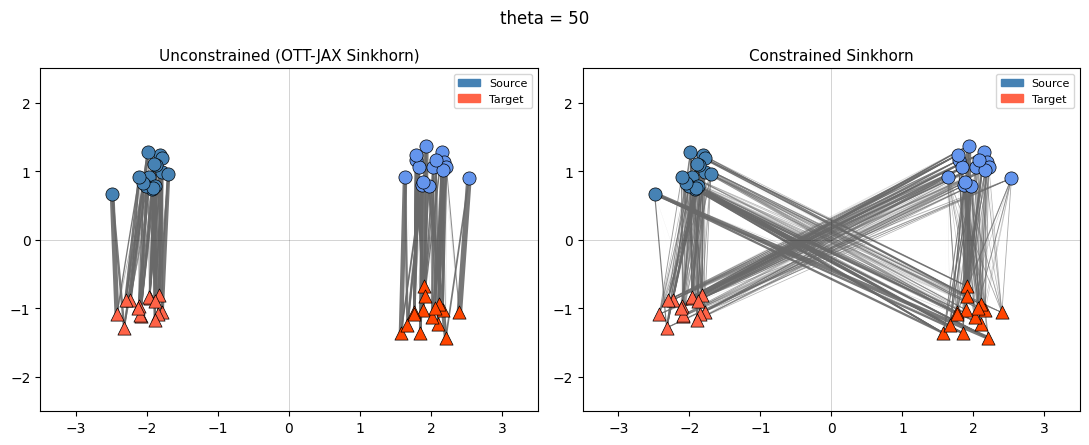

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
draw_transport(axes[0], xs, xt, P_free,
               title="Unconstrained (OTT-JAX Sinkhorn)", half=half)
draw_transport(axes[1], xs, xt, P_cst,
               title=f"Constrained Sinkhorn", half=half)
plt.suptitle(f"theta = {theta:.0f}", fontsize=12)
plt.tight_layout(); plt.show()

as we see, our method with inequality constraint has indeed higher overall cost , as it privileges cross connections

As for the convergence, we can also track the convergence of the metrics, as we see the cost is going down and errors tend to zero with training time, so our P matrix respects the marginal constraints and inequality constraint

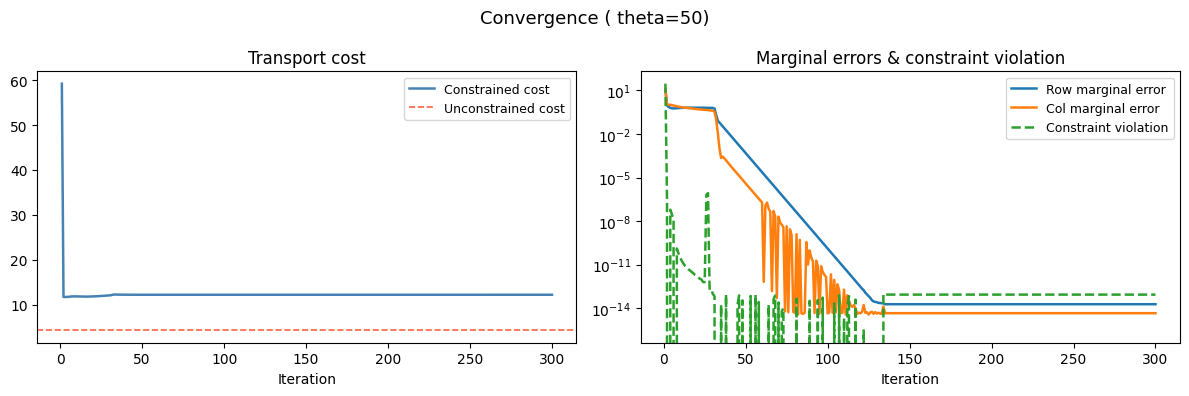

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
iters = np.arange(1, len(costs) + 1)

axes[0].plot(iters, costs, color="steelblue", lw=1.8, label="Constrained cost")
axes[0].axhline(float(ot_out.reg_ot_cost), color="tomato", ls="--", lw=1.2,
                label="Unconstrained cost")
axes[0].set_title("Transport cost", fontsize=12)
axes[0].set_xlabel("Iteration"); axes[0].legend(fontsize=9)

axes[1].semilogy(iters, row_errs,   lw=1.8, label="Row marginal error")
axes[1].semilogy(iters, col_errs,   lw=1.8, label="Col marginal error")
axes[1].semilogy(iters, violations, lw=1.8, ls="--", label="Constraint violation")
axes[1].set_title("Marginal errors & constraint violation", fontsize=12)
axes[1].set_xlabel("Iteration"); axes[1].legend(fontsize=9)

plt.suptitle(f"Convergence ( theta={theta:.0f})", fontsize=13)
plt.tight_layout(); plt.show()